<a href="https://colab.research.google.com/github/victoriabrowwn/lab---3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Victoria Brown Afari
**Student ID:** 94692028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

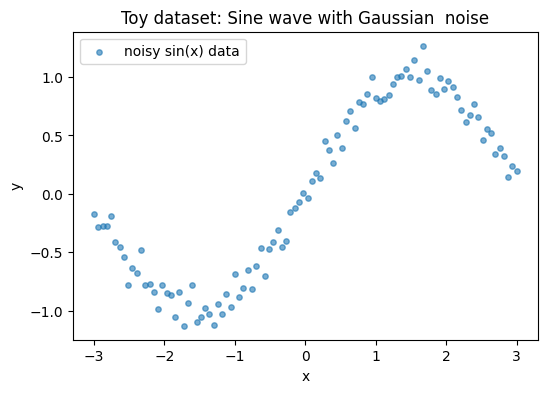

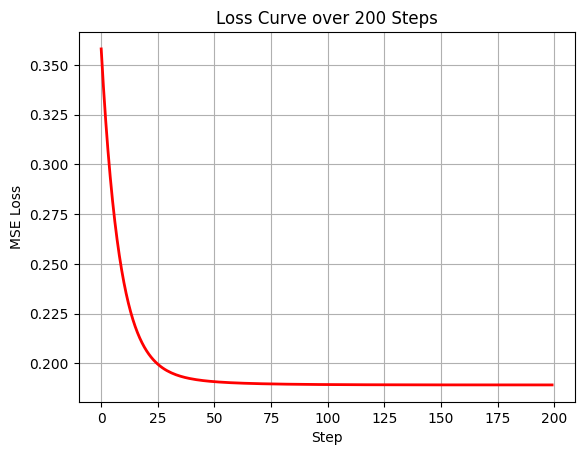

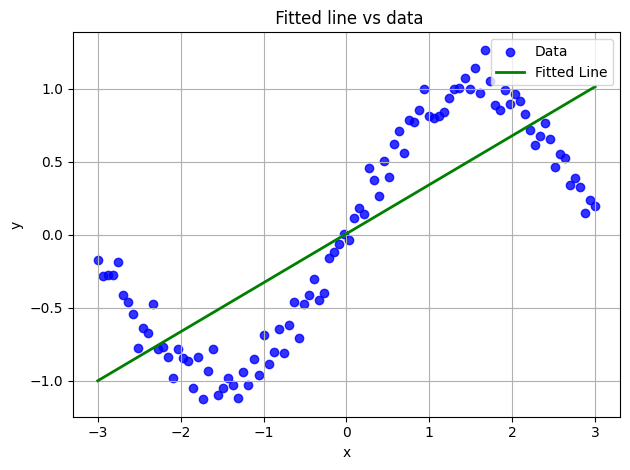

In [3]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)

#   Plot it.
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15,alpha=0.6, label="noisy sin(x) data")
plt.title("Toy dataset: Sine wave with Gaussian  noise")
plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.show()



# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.01
losses = []

for step in range(200):
  y_hat = w * x + b
  loss = np.mean((y_hat - y) ** 2)
  dw = np.mean(2 * (y_hat - y) * x)
  db = np.mean(2 * (y_hat - y))
  w -= lr * dw
  b -= lr * db
  losses.append(loss)
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.plot(losses, color='red', lw=2)
plt.title("Loss Curve over 200 Steps")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


plt.scatter(x, y, color='blue', alpha=0.8, label='Data')
plt.plot(x, w * x + b, color='green', lw=2, label=f'Fitted Line')
plt.title(" Fitted line vs data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:**
1. 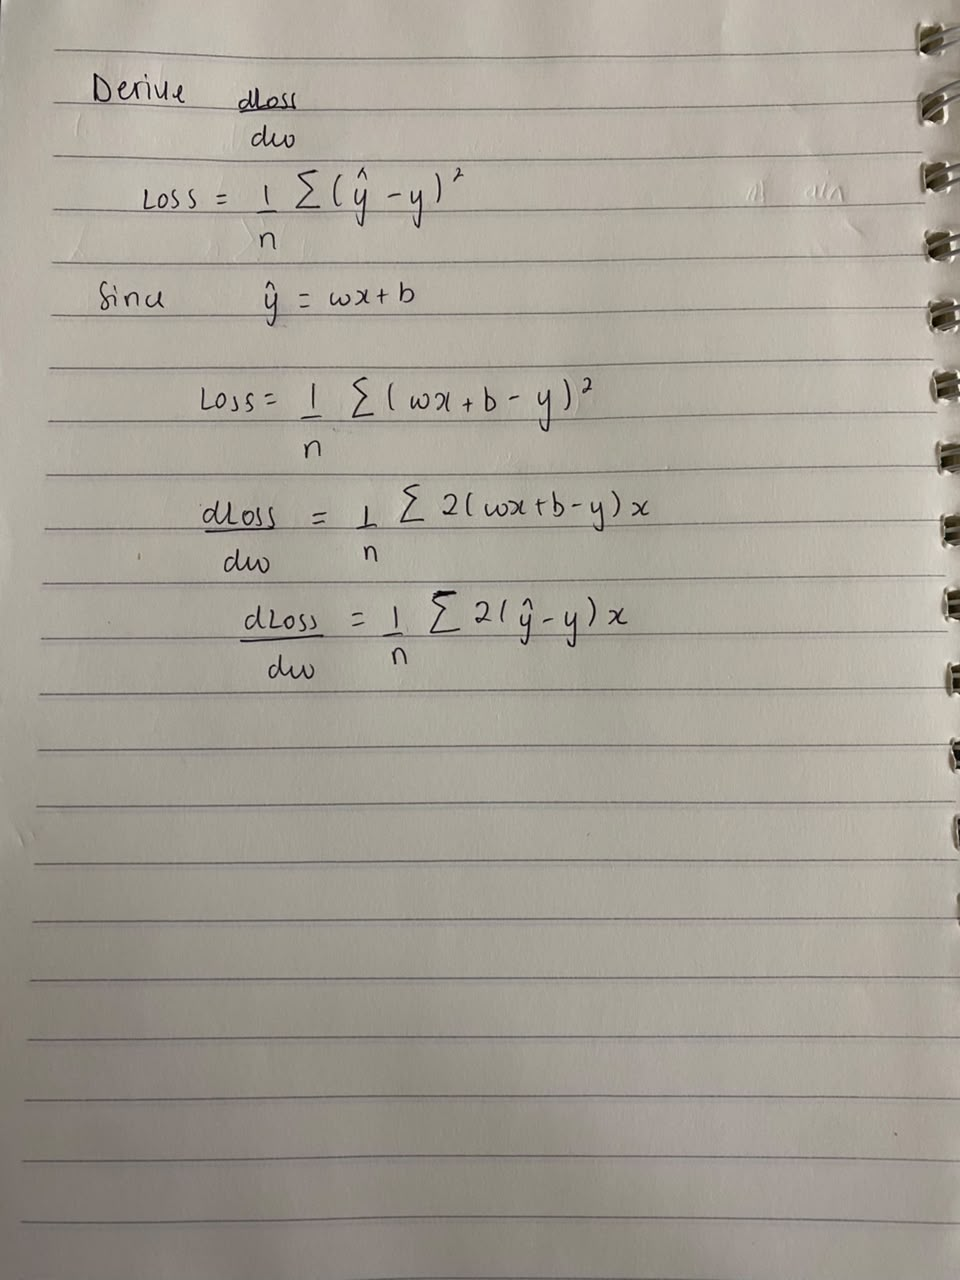

2. The model is underfitting because a single neuron can only learn a linear relationship of the form y = wx + b. A single neuron can never fit a sine wave no matter how long you train because a sine wave is non linear so it can only produce the best possible straight line through the data.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

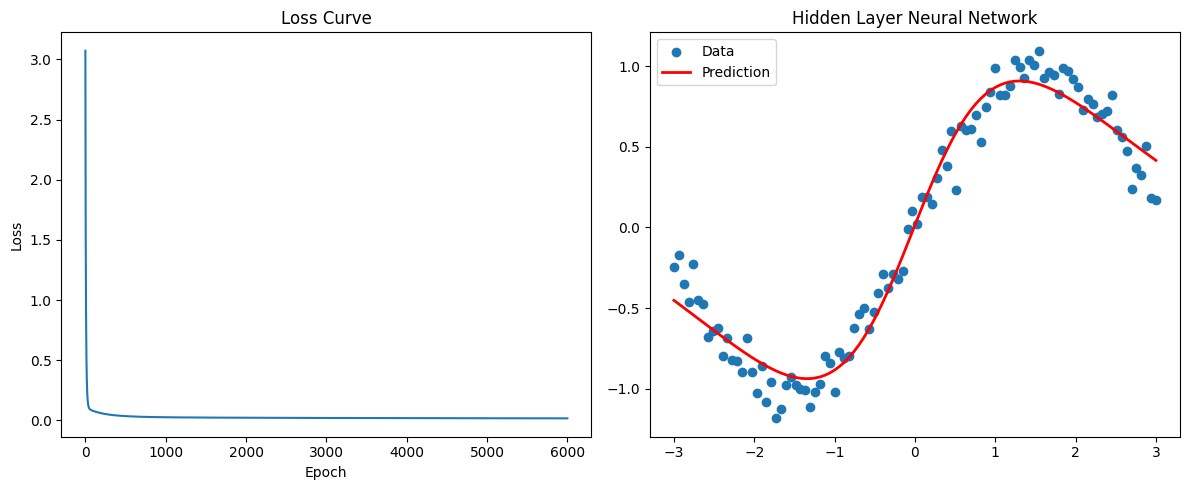

In [4]:
# TODO: Initialise parameters
np.random.seed(42)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

lr = 0.01
losses = []

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~3000 steps:

#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
for epoch in range(3000):

    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    # Loss
    loss = np.mean((y_hat - y) ** 2)

    # Backpropagation

    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Gradient descent update

    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)

dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

# TRAIN THE NETWORK
for step in range(3000):

    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    # Loss
    loss = np.mean((y_hat - y) ** 2)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Gradient descent
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)

# TODO: Plot the loss curve AND the final fit over the data.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", linewidth=2, label="Prediction")
plt.legend()
plt.title("Hidden Layer Neural Network")

plt.tight_layout()
plt.show()
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. Without the tanh activation, every layer performs only a linear transformation. If the hidden layer is
h =  XW1 + b1, then the output is Y = hW2 + b2

Substituting,
Y = (WX1 + b1) w2 + b2
Y = X(W1W2) + (b1W2 + b2)

This is still a single linear equation in the form Y = XW + b
Therefore, stacking multiple linear layers without a nonlinear activation is mathematically equivalent to another linear layer.

2. Each hidden neuron learned a different nonlinear transformation of the input using the tanh activation. The eight neurons produced different features of thr input, and the output layer combined these features to approximate the sine curve.

3. Backpropagationis the algorithm that computes the gradient of the loss with respect to every parameter in the network by applying the the chain rule from the output layer back to the input layer, allowing gradient descent to update the weigths efficiently.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/tmp/ipykernel_1140/1298845700.py:23: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_1140/1298845700.py:31: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_1140/1298845700.py:32: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


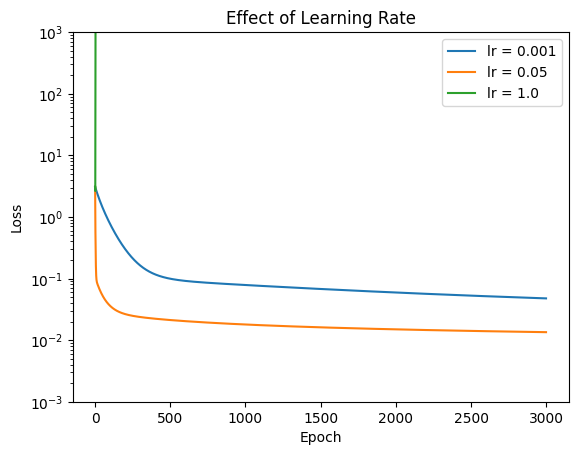

In [7]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):

    # Reset weights for a fair comparison
    np.random.seed(42)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    losses = []

    for step in range(steps):

        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - y) ** 2)

        # Backpropagation
        d_yhat = 2 * (y_hat - y) / len(y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Gradient descent
        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

        losses.append(loss)

    return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
loss_small = train_toy(0.001)
loss_medium = train_toy(0.05)
loss_large = train_toy(1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
#plt.figure(figsize=(8,6))

plt.plot(range(3000), loss_small, label="lr = 0.001")
plt.plot(range(3000), loss_medium, label="lr = 0.05")
plt.plot(range(3000), loss_large, label="lr = 1.0")

plt.yscale("log")
plt.ylim(1e-3, 1e3)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")
plt.legend()

plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:**

The curve with learning rate = 0.001 decreases gradually because the weight updates are very small. The model learns in the correct direction, but convergence is slow and requires many iterations.

The curve with learning rate = 0.05 decreases rapidly and then stabilizes at a low value. This learning rate provides a good balance between speed and stability, allowing the network to converge efficiently.

The curve with learning rate = 1.0 diverges because the parameter updates are too large. nstead of moving closer to the minimum of the loss function, each update overshoots it, causing the parameters to jump back and forth or move farther away. As a result, the loss may increase dramatically or fail to converge.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [8]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
binary_cols = ["family_history_with_overweight", "FAVC", "SCC", "SMOKE"]
n_obesity = obesity.copy()
n_obesity[binary_cols] = n_obesity[binary_cols].replace({"yes": 1, "no": 0})
ordinal_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
n_obesity["CAEC"] = n_obesity["CAEC"].map(ordinal_map)
n_obesity["CALC"] = n_obesity["CALC"].map(ordinal_map)
n_obesity = pd.get_dummies(n_obesity, columns=["Gender", "MTRANS"])
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
n_obesity["NObeyesdad"] = le.fit_transform(n_obesity["NObeyesdad"])
from sklearn.model_selection import train_test_split

n_obesity["NObeyesdad"] = le.fit_transform(n_obesity["NObeyesdad"])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X_ob = n_obesity.drop(columns=["NObeyesdad"])
Y_ob = n_obesity["NObeyesdad"]
X_ob_TV, X_ob_test, Y_ob_TV, Y_ob_test = train_test_split(
    X_ob, Y_ob, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_ob
)
Xob_train, Xob_val, Yob_train, Yob_val = train_test_split(
    X_ob_TV, Y_ob_TV, test_size=0.25, random_state=RANDOM_STATE, stratify=Y_ob_TV
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
from sklearn.preprocessing import StandardScaler

ob_scaler = StandardScaler()
Xob_train = ob_scaler.fit_transform(Xob_train)
Xob_val = ob_scaler.transform(Xob_val)
X_ob_test = ob_scaler.transform(X_ob_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_t = torch.tensor(Xob_train, dtype=torch.float32)
Y_train_t = torch.tensor(Yob_train.values, dtype=torch.long)
X_val_t = torch.tensor(Xob_val, dtype=torch.float32)
Y_val_t = torch.tensor(Yob_val.values, dtype=torch.long)
X_test_t = torch.tensor(X_ob_test, dtype=torch.float32)
Y_test_t = torch.tensor(Y_ob_test.values, dtype=torch.long)

XTr_set = TensorDataset(X_train_t, Y_train_t)
XTr_loader = DataLoader(XTr_set, batch_size=32, shuffle=True)
XVl_set = TensorDataset(X_val_t, Y_val_t)
XVl_loader = DataLoader(XVl_set, batch_size=32, shuffle=False)
XTst_set = TensorDataset(X_test_t, Y_test_t)
XTst_loader = DataLoader(XTst_set, batch_size=32, shuffle=False)

/tmp/ipykernel_1140/4237196330.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  n_obesity[binary_cols] = n_obesity[binary_cols].replace({"yes": 1, "no": 0})


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:**

1. Because it is memory efficient.

2. Some of the data depend directly on the input values.If some features have much larger numerical values than others, they produce much larger gradients, causing unstable or uneven learning. Standardizing the features puts them on similar scales, leading to more stable gradient updates and faster convergence. Random forests split data based on feature thresholds rather than gradient-based optimization, so they are largely unaffected by feature scaling.

3. Randomizes the order of the training samples at the start of every epoch.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [17]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev_size = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

        #return self.network(x)

model = FeedForwardNet(input_dim=X_train_t.shape[1])
model.to(DEVICE)



print(X_train_t.shape[1])
print(X_train_t.shape[1] * 64 + 64)
print(sum(p.numel() for p in model.net[0].parameters() if p.requires_grad))
#print(sum(p.numel() for p in model.parameters() if p.requires_grad))



21
1408
1408
3719


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**

1. The network architecture is 21 → 64 → 32 → 7
Layer 1 (Input → 64 neurons):

Weights = 21 x 64=1344
Biases = 64
Total parameters = 1344+64=1408

ayer 2 (64 → 32 neurons):

Weights = 64 x 32=2048
Biases = 32
Total parameters = 2048+32=2080

Output Layer (32 → 7 neurons):

Weights = 32 x 7=224
Biases = 7
Total parameters = 224+7=231

Total trainable parameters:

1408+2080+231=3719

The manually calculated total is 3719 trainable parameters, which matches the value returned by PyTorch

2. ReLU is used because it trains deep neural networks more efficiently than tanh. It reduces the vanishing gradient problem, allowing the network to converge faster and making it easier to train deeper models.

3. If the ReLU activation functions were removed, every layer would perform only a linear transformation. The composition of several linear transformations is still a single linear transformation, so the entire network would be equivalent to one linear layer.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 1: train_loss=1.7321, val_loss=1.7470, train_acc=0.4700, val_acc=0.4526
Epoch 2: train_loss=1.3741, val_loss=1.3924, train_acc=0.5284, val_acc=0.5095
Epoch 3: train_loss=1.0947, val_loss=1.1067, train_acc=0.6177, val_acc=0.5829
Epoch 4: train_loss=0.9049, val_loss=0.9151, train_acc=0.6659, val_acc=0.6588
Epoch 5: train_loss=0.7791, val_loss=0.8001, train_acc=0.7536, val_acc=0.7393
Epoch 6: train_loss=0.6777, val_loss=0.7068, train_acc=0.7804, val_acc=0.7583
Epoch 7: train_loss=0.5966, val_loss=0.6387, train_acc=0.7930, val_acc=0.7678
Epoch 8: train_loss=0.5232, val_loss=0.5760, train_acc=0.8294, val_acc=0.7915
Epoch 9: train_loss=0.4645, val_loss=0.5304, train_acc=0.8705, val_acc=0.8389
Epoch 10: train_loss=0.4102, val_loss=0.4832, train_acc=0.8744, val_acc=0.8341
Epoch 11: train_loss=0.3628, val_loss=0.4403, train_acc=0.9021, val_acc=0.8626
Epoch 12: train_loss=0.3221, val_loss=0.4068, train_acc=0.9092, val_acc=0.8555
Epoch 13: train_loss=0.2939, val_loss=0.3880, train_acc=0.917

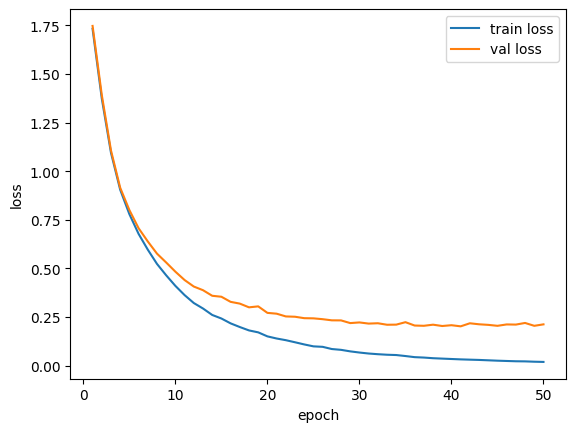

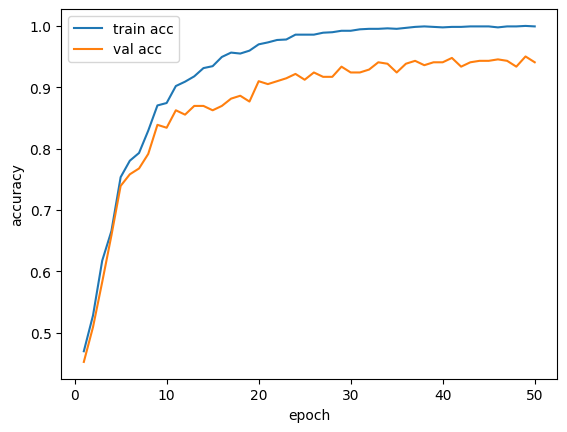

In [14]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
def evaluate(loader, model, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * xb.size(0)
            total_correct += (preds == yb).sum().item()
            total_samples += xb.size(0)
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(50):
    model.train()
    for xb, yb in XTr_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(XTr_loader, model, criterion)
    val_loss, val_acc = evaluate(XVl_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    print(
        f"Epoch {epoch + 1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
        f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}"
    )


# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
epochs_range = range(1, 51)

plt.plot(epochs_range, history["train_loss"], label="train loss")
plt.plot(epochs_range, history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.plot(epochs_range, history["train_acc"], label="train acc")
plt.plot(epochs_range, history["val_acc"], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

Epoch 1: train_loss=1.8730, val_loss=1.8771, train_acc=0.2227, val_acc=0.2204
Epoch 2: train_loss=1.7821, val_loss=1.7904, train_acc=0.3641, val_acc=0.3318
Epoch 3: train_loss=1.6818, val_loss=1.6934, train_acc=0.4439, val_acc=0.4384
Epoch 4: train_loss=1.5846, val_loss=1.5983, train_acc=0.4629, val_acc=0.4550
Epoch 5: train_loss=1.4946, val_loss=1.5086, train_acc=0.5063, val_acc=0.5071
Epoch 6: train_loss=1.4144, val_loss=1.4254, train_acc=0.5118, val_acc=0.5118
Epoch 7: train_loss=1.3462, val_loss=1.3545, train_acc=0.5419, val_acc=0.5308
Epoch 8: train_loss=1.2846, val_loss=1.2898, train_acc=0.5600, val_acc=0.5616
Epoch 9: train_loss=1.2286, val_loss=1.2309, train_acc=0.5806, val_acc=0.5782
Epoch 10: train_loss=1.1781, val_loss=1.1770, train_acc=0.5924, val_acc=0.6137
Epoch 11: train_loss=1.1340, val_loss=1.1319, train_acc=0.6051, val_acc=0.6209
Epoch 12: train_loss=1.0928, val_loss=1.0901, train_acc=0.6137, val_acc=0.6303
Epoch 13: train_loss=1.0559, val_loss=1.0530, train_acc=0.632

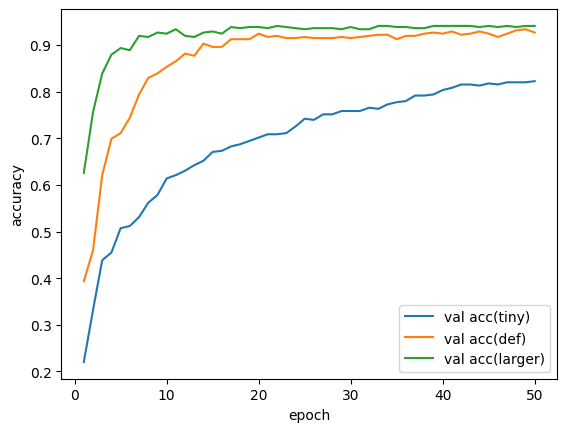

Epoch 1: train_loss=1.9423, val_loss=1.9442, train_acc=0.1169, val_acc=0.1161
Epoch 2: train_loss=1.9242, val_loss=1.9268, train_acc=0.1493, val_acc=0.1351
Epoch 3: train_loss=1.9055, val_loss=1.9088, train_acc=0.2425, val_acc=0.2204
Epoch 4: train_loss=1.8851, val_loss=1.8891, train_acc=0.3041, val_acc=0.2915
Epoch 5: train_loss=1.8630, val_loss=1.8674, train_acc=0.3349, val_acc=0.3199
Epoch 6: train_loss=1.8383, val_loss=1.8433, train_acc=0.4534, val_acc=0.4360
Epoch 7: train_loss=1.8110, val_loss=1.8168, train_acc=0.4937, val_acc=0.4787
Epoch 8: train_loss=1.7800, val_loss=1.7869, train_acc=0.5253, val_acc=0.5308
Epoch 9: train_loss=1.7459, val_loss=1.7539, train_acc=0.5355, val_acc=0.5332
Epoch 10: train_loss=1.7084, val_loss=1.7179, train_acc=0.5419, val_acc=0.5284
Epoch 11: train_loss=1.6672, val_loss=1.6781, train_acc=0.5387, val_acc=0.5261
Epoch 12: train_loss=1.6228, val_loss=1.6354, train_acc=0.5427, val_acc=0.5261
Epoch 13: train_loss=1.5752, val_loss=1.5896, train_acc=0.543

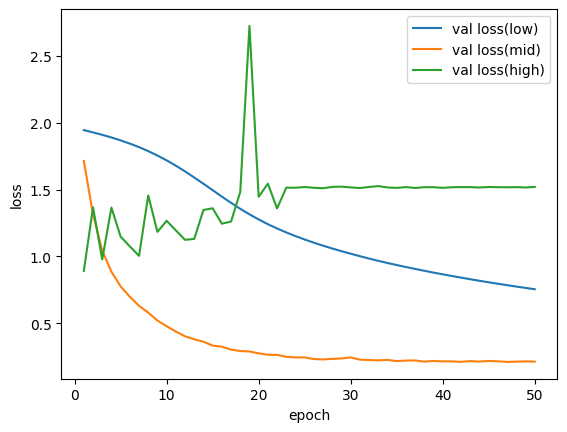

Epoch 1: train_loss=1.3527, val_loss=1.3753, train_acc=0.5261, val_acc=0.5000
Epoch 2: train_loss=0.8282, val_loss=0.8778, train_acc=0.6532, val_acc=0.6422
Epoch 3: train_loss=0.6249, val_loss=0.6789, train_acc=0.7938, val_acc=0.7607
Epoch 4: train_loss=0.4776, val_loss=0.5229, train_acc=0.8641, val_acc=0.8294
Epoch 5: train_loss=0.4175, val_loss=0.4702, train_acc=0.8736, val_acc=0.8365
Epoch 6: train_loss=0.3134, val_loss=0.3862, train_acc=0.9068, val_acc=0.8626
Epoch 7: train_loss=0.2809, val_loss=0.3659, train_acc=0.8997, val_acc=0.8483
Epoch 8: train_loss=0.2595, val_loss=0.3547, train_acc=0.9068, val_acc=0.8720
Epoch 9: train_loss=0.2025, val_loss=0.2964, train_acc=0.9384, val_acc=0.8910
Epoch 10: train_loss=0.1805, val_loss=0.2943, train_acc=0.9408, val_acc=0.8886
Epoch 11: train_loss=0.1819, val_loss=0.2983, train_acc=0.9352, val_acc=0.8934
Epoch 12: train_loss=0.1551, val_loss=0.2543, train_acc=0.9605, val_acc=0.9028
Epoch 13: train_loss=0.1307, val_loss=0.2521, train_acc=0.968

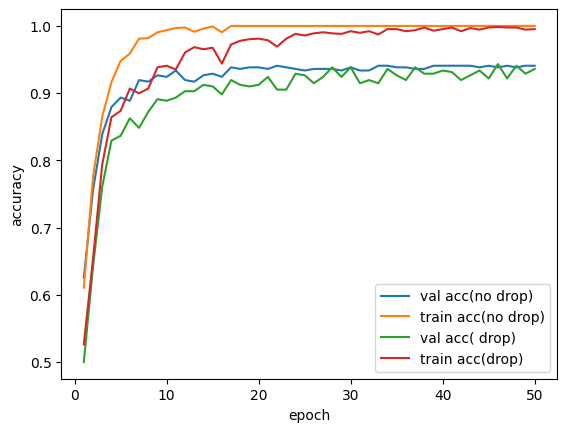

Epoch 1: train_loss=1.0744, val_loss=1.1094, train_acc=0.6343, val_acc=0.6280
Epoch 2: train_loss=0.6107, val_loss=0.6699, train_acc=0.8081, val_acc=0.7820
Epoch 3: train_loss=0.4039, val_loss=0.4762, train_acc=0.8902, val_acc=0.8673
Epoch 4: train_loss=0.2994, val_loss=0.4135, train_acc=0.8847, val_acc=0.8555
Epoch 5: train_loss=0.1968, val_loss=0.3205, train_acc=0.9502, val_acc=0.9076
Epoch 6: train_loss=0.1671, val_loss=0.2850, train_acc=0.9542, val_acc=0.9076
Epoch 7: train_loss=0.1175, val_loss=0.2826, train_acc=0.9763, val_acc=0.9076
Epoch 8: train_loss=0.1066, val_loss=0.3000, train_acc=0.9684, val_acc=0.8957
Epoch 9: train_loss=0.0658, val_loss=0.2385, train_acc=0.9889, val_acc=0.9218
Epoch 10: train_loss=0.0698, val_loss=0.2749, train_acc=0.9842, val_acc=0.9147
Epoch 11: train_loss=0.0611, val_loss=0.2677, train_acc=0.9882, val_acc=0.9194
Epoch 12: train_loss=0.0397, val_loss=0.2300, train_acc=0.9945, val_acc=0.9360
Epoch 13: train_loss=0.0270, val_loss=0.2522, train_acc=0.998

In [15]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(
    hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0
):
    model = FeedForwardNet(
        input_dim=X_train_t.shape[1], hidden_sizes=hidden_sizes, dropout=dropout
    )
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    XTr_loader = DataLoader(XTr_set, batch_size=batch_size, shuffle=True)
    XVl_loader = DataLoader(XVl_set, batch_size=batch_size, shuffle=False)
    XTst_loader = DataLoader(XTst_set, batch_size=batch_size, shuffle=False)

    for epoch in range(epochs):
        model.train()
        for xb, yb in XTr_loader:
            optimizer.zero_grad()
            logits = model(xb.to(DEVICE))
            loss = criterion(logits, yb.to(DEVICE))
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(XTr_loader, model, criterion)
        val_loss, val_acc = evaluate(XVl_loader, model, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "ffn_best.pt")

        print(
            f"Epoch {epoch + 1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
            f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}"
        )
    return history


# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
tinyExp = run_experiment(hidden_sizes=(8,))
defExp = run_experiment()
largeExp = run_experiment(hidden_sizes=(256, 128, 64))
#   Plot the three validation-accuracy curves together.
plt.plot(epochs_range, tinyExp["val_acc"], label="val acc(tiny)")
plt.plot(epochs_range, defExp["val_acc"], label="val acc(def)")
plt.plot(epochs_range, largeExp["val_acc"], label="val acc(larger)")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()


# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
loLR = run_experiment(lr=1e-4)
meLR = run_experiment(lr=1e-3)
HiLR = run_experiment(lr=1e-1)
#   Plot the three validation-loss curves together. Compare with Part 1.3.
plt.plot(epochs_range, loLR["val_loss"], label="val loss(low)")
plt.plot(epochs_range, meLR["val_loss"], label="val loss(mid)")
plt.plot(epochs_range, HiLR["val_loss"], label="val loss(high)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()


# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
largeExp2 = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)
plt.plot(epochs_range, largeExp["val_acc"], label="val acc(no drop)")
plt.plot(epochs_range, largeExp["train_acc"], label="train acc(no drop)")
plt.plot(epochs_range, largeExp2["val_acc"], label="val acc( drop)")
plt.plot(epochs_range, largeExp2["train_acc"], label="train acc(drop)")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()
largeExp = run_experiment(hidden_sizes=(256, 128, 64))

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test accuracy: 0.9456
Test macro-F1: 0.9456
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        54
           1       0.94      0.88      0.91        58
           2       0.90      0.99      0.94        70
           3       0.98      0.92      0.95        60
           4       1.00      0.98      0.99        65
           5       0.87      0.93      0.90        58
           6       0.96      0.91      0.94        58

    accuracy                           0.95       423
   macro avg       0.95      0.94      0.95       423
weighted avg       0.95      0.95      0.95       423



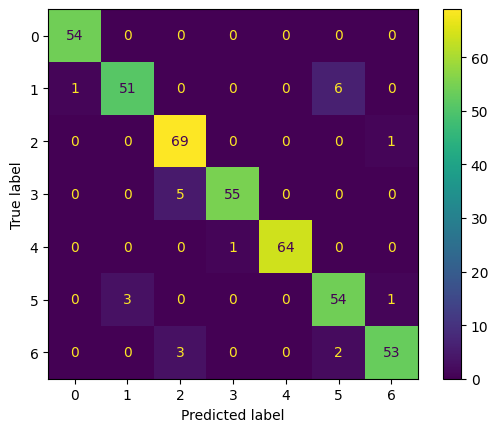

47239


,Model,Test Accuracy,Test Macro-F1,Training Time,Parameters/Trees
0,Logistic Regression (Lab 2),0.853400,0.847700,not recorded,154
1,Feedforward NN (Lab 3),0.945626,0.945556,not recorded,47239


In [16]:
# TODO: Load your best configuration's weights; model.eval().
bestMod = FeedForwardNet(input_dim=X_train_t.shape[1], hidden_sizes=(256, 128, 64))
bestMod.to(DEVICE)
bestMod.load_state_dict(torch.load("ffn_best.pt"))
evaluate(XTst_loader, bestMod, criterion)

# TODO: Report test ACCURACY and MACRO-F1
from sklearn.metrics import accuracy_score, f1_score, classification_report

bestMod.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in XTst_loader:
        logits = bestMod(xb.to(DEVICE))
        preds = logits.argmax(dim=1)
        all_labels.extend(yb.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())


test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro-F1: {test_f1:.4f}")
print(classification_report(all_labels, all_preds))

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=le.classes_
)
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
print(sum(p.numel() for p in bestMod.parameters() if p.requires_grad))
comparison = pd.DataFrame(
    {
        "Model": ["Logistic Regression (Lab 2)", "Feedforward NN (Lab 3)"],
        "Test Accuracy": [0.8534, test_acc],
        "Test Macro-F1": [0.8477, test_f1],
        "Training Time": ["not recorded", "not recorded"],
        "Parameters/Trees": [154, 47239],
    }
)
comparison

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.